# Анализ рынка заведений общественного питания Москвы

### Цели и задачи проекта

В этой работе используется датасет, содержащий в себе данные о заведениях общественного питания Москвы. Необходимо проанализировать его данные и предоставить инвесторам актуальную информацию об объектах питания в Москве, чтобы они смогли подобрать оптимальный для себя тип заведения, его расположение и т.д. для открытия новой точки.

В ходе выполнения работы ознакомимся с датасетом, проведем его предобработку и реализуем исследовательский анализ данных.

### Содержимое проекта

1. [Загрузка данных и знакомство с ними.](#1-bullet)
2. [Предобработка данных.](#2-bullet)
3. [Исследовательский анализ данных.](#3-bullet)<br>
    3.1 [Задача 1](#3.1-bullet)<br>
    3.2 [Задача 2](#3.2-bullet)<br>
    3.3 [Задача 3](#3.3-bullet)<br>
    3.4 [Задача 4](#3.4-bullet)<br>
    3.5 [Задача 5](#3.5-bullet)<br>
    3.6 [Задача 6](#3.6-bullet)<br>
    3.7 [Задача 7](#3.7-bullet)<br>
    3.8 [Задача 8](#3.8-bullet)<br>
4. [Итоговый вывод и рекомендации](#4-bullet)<br>
---

<a class="anchor" id="1-bullet"></a>
## 1. Загрузка данных и знакомство с ними


Загрузим датасеты.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from phik import phik_matrix
import numpy as np
import seaborn as sns

In [2]:
try:
    df_info = pd.read_csv('/datasets/rest_info.csv') 
    df_price = pd.read_csv('/datasets/rest_price.csv')
except:
    df_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv') 
    df_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv') 

Ознакомимся с данными датасета rest_info.

In [4]:
df_info.shape

(8406, 9)

In [5]:
df_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
df_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


Ознакомимся с данными датасета rest_price.

In [7]:
df_price.shape

(4058, 5)

In [8]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [9]:
df_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### Промежуточный вывод


В результате знакомства с данными можно сделать выводы:
- размер датасета `rest_info` - 8406 строк и 9 столбцов, `rest_price` - 4058 строк и 5 столбцов;
- описания данных соответствуют фактическим данным;
- столбцы датасета `rest_info`, типы данных которых стоит изменить: 
    - `rating`: сократить разрядность, так как значения заключены в пределах пяти; 
    - `chain`: сократить разрядность, так как значения столбца могут принимать значения только 0 и 1;
    - `seats`: заменить на целочисленный, так как количество посадочных мест - целое число.
- типы данных столбцов датасета `rest_price` менять не надо;
- пропуски датасета `rest_info` встречаются в столбцах: `hours`, `seats`;
- пропуски датасета `rest_price` встречаются во всех столбцах: `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`.

При предобработке стоит обратить внимание на то, что:
- в датасете `rest_info` могут быть ошибки в столбце `chain` для маленьких сетей (из условия);
- если понадобится работать с часами работы заведений, за счет указания дней недели, с ними нельзя работать как со временем;
- в датасете `rest_price` в столбцах `middle_avg_bill`, `middle_coffee_cup` есть много пропусков (особенно в `middle_coffee_cup`). 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

### Подготовка единого датафрейма


Объединим данные двух датасетов в один, с которым продолжим работу.

In [3]:
df = df_info.merge(df_price, how='left')

In [4]:
df.shape

(8406, 13)

Создадим копию датасета до преобразования для возможности проверить сделанные изменения после предобработки.

In [5]:
temp = df.copy() 
len(temp)

8406

<a class="anchor" id="2-bullet"></a>
## 2. Предобработка данных

Подготовим данные к исследовательскому анализу:

- Изучим корректность типов данных и при необходимости проведем их преобразование.

Стиль написания названий столбцов не будем изменять, так как он уже имеет вид snake case.

Повторно проверим типы данных и изменим их.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), str(8)
memory usage: 853.9 KB


Преобразуем типы данных столбцов `rating`, `chain`, `seats`.

In [7]:
# сократим разрядность столбца rating
df['rating'] = pd.to_numeric(df['rating'], downcast='float')

In [8]:
# сократим разрядность столбца chain
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

Проанализируем пропуски в столбце `seats`, прежде чем изменить тип.

In [9]:
round((df['seats'].isna().sum() / df.shape[0]) * 100, 3)

np.float64(42.957)

В столбце `seats` почти 43% пропусков.

Проверим, зависят ли пропуски от типа заведения. Возможно, есть заведения, изначально не предполагающие под собой наличие сидячих мест.

In [10]:
# создадим датафрейм для проверки
df_check = pd.DataFrame({
    'is_know_seats': df['seats'].isna(),
    'category': df['category']
})
df_check

,is_know_seats,category
0,True,кафе
1,False,ресторан
2,False,кафе
3,True,кофейня
4,False,пиццерия
...,...,...
8401,False,кафе
8402,False,кафе
8403,False,кафе
8404,False,кафе


In [11]:
# сгруппируем данные по категориям заведения
check_grouped = df_check.groupby('category')['is_know_seats'].sum()
check_grouped

category
бар,паб             297
булочная            108
быстрое питание     254
кафе               1160
кофейня             662
пиццерия            206
ресторан            773
столовая            151
Name: is_know_seats, dtype: int64

<Axes: title={'center': 'Проверка зависимости отсутствия информации о количестве мест в заведении от типа заведения'}, xlabel='Тип заведения', ylabel='Количество заведений без информации'>

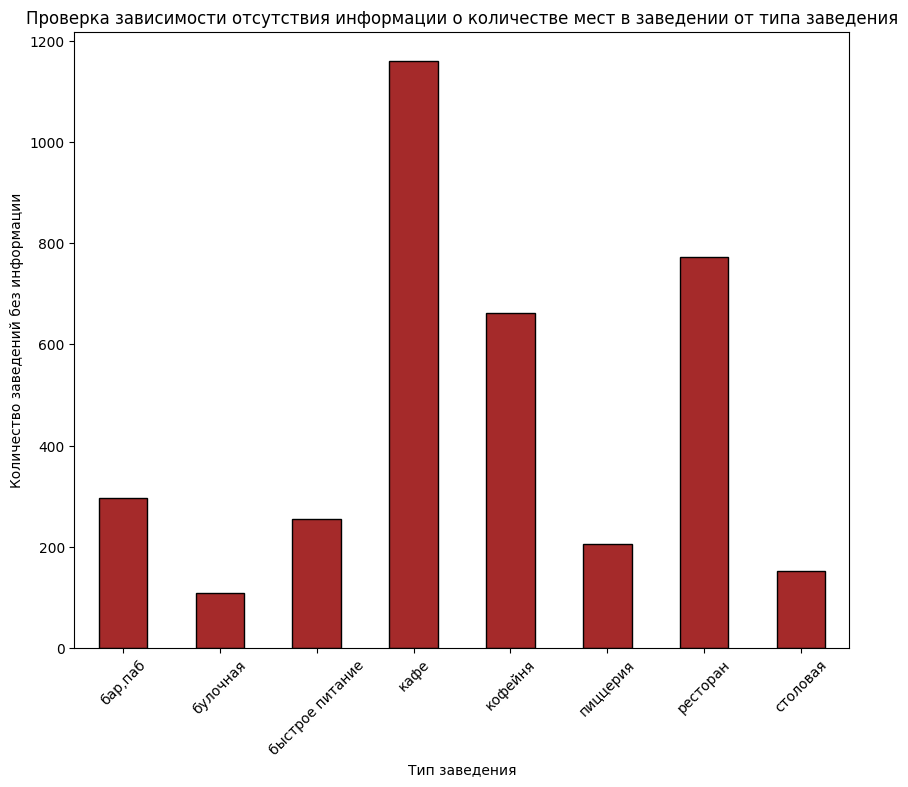

In [12]:
check_grouped.plot(kind='bar', xlabel='Тип заведения', ylabel='Количество заведений без информации', title='Проверка зависимости отсутствия информации о количестве мест в заведении от типа заведения', color='brown', edgecolor='black', rot=45, figsize=(10, 8))

По графику можно увидеть, что количество пропусков в столбце с количеством мест не зависит от типа заведения.

Вероятно, ни от каких других столбцов датафрейма не зависит, указана ли информация о количестве мест в заведении. 

Так как в датафрейме нет информации, которая помогала бы выявить логику пропусков, данные точно имеют тип не MAR. Нельзя точно сказать, являтся ли пропуски MNAR или MCAR.

Так как пропусков много, заменим их значение-индикатором. Проверим минимальное значение в столбце, чтобы убедиться, что в столбец не были по ошибке занесены отрицательные данные.

In [13]:
df['seats'].min()

np.float64(0.0)

Заменим все пропуски значением-индикатором, равным -1.

In [14]:
df['seats'] = df['seats'].fillna(-1)

In [15]:
# преобразуем тип столбца seats
df['seats'] = df['seats'].astype('int64')

Понизим разрядность числовых данных столбцов `middle_avg_bill`, `middle_coffee_cu` с 64 до 32.

In [16]:
for column in ['middle_avg_bill','middle_coffee_cup']:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              8406 non-null   int64  
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(3), int64(1), int8(1), str(8)
memory usage: 697.9 KB


Все типы данных столбцов были корректно преобразованы.

- Изучим пропущенные значения в данных, проведем их обработку.

In [19]:
# посчитаем абсолютное количество пропущенных значений
df.isna().sum().sort_values()

id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
seats                   0
hours                 536
avg_bill             4590
price                5091
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [20]:
# посчитаем относительное количество пропущенных значений
round((df.isna().sum() / df.shape[0]) * 100, 2).sort_values()

id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
rating                0.00
chain                 0.00
seats                 0.00
hours                 6.38
avg_bill             54.60
price                60.56
middle_avg_bill      62.54
middle_coffee_cup    93.64
dtype: float64

Напишем функцию для отображения статистики пропущенных значений в DataFrame.

In [22]:
def show_missing_stats(tmp0):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0].sort_values(by='Кол-во пропусков')
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
avg_bill,4590,0.5460
price,5091,0.6056
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


С учетом обработки пропусков в `seats`, пропуски так же содержатся в столбцах:
- `hours`;
- `price`;
- `avg_bill`;
- `middle_avg_bill`;
- `middle_coffee_cup`.

Наименьшее количество пропусков содержится в столбце `hours`, наибольшее - в столбце `middle_coffee_cup`.

Предположения о причинах пропусков:
- возможно, пропуски в `hours` имеют тип MNAR и они не были указаны владельцами заведений из-за факторов, которых нет в наборе данных. Это могут быть маленькие заведения, владельцы которых не знают о подобной функции добавления времени работы заведения, либо за счет маленького потока людей данные добавить было некому;
- возможно, пропуски в `price` и `avg_bill` так же имеют тип MNAR и появляются из-за того, что на сайты владельцами либо посетителями не была добавлена информация о меню/ценах на блюда;
- пропуски в `middle_avg_bill`, `middle_coffee_cup` встречаются, потому что они строятся по столбцу `avg_bill`, в котором есть пропуски. Так же из-за того, что эти столбцы строятся только по определенным строкам `avg_bill` (начинающихся с «Средний счёт» или «Цена одной чашки капучино»).

Проверим, какие столбцы из столбцов с пропусками будут использоваться в дальнейшем анализе. Получим:
- `hours`: для создания столбца `is_24_7`;
- `price`: для задания 6;
- `middle_avg_bill`: для задания 8.

На основе проверки сделаем предложения по обработке пропусков:
- пропуски в столбцах, не используемых для дальнейшего анализа (`avg_bill`, `middle_coffee_cup`), обрабатывать не будем;
- столбец `hours`: так как нельзя восстановить время работы заведений, заменим пропуски значением-индикатором - пустой строкой;
- столбцы `price`и `middle_avg_bill`: количество пропусков очень большое, данные будут сильно искажены, если заменить их (например, заполнение наиболее частыми значениями в группах не подойдет). Их так же заменим значениями-индикаторами (пустой строкой и -1 соответственно). 

Обработаем пропуски столбца `hours`. 

In [23]:
df['hours'] = df['hours'].fillna("")

Обработаем пропуски столбцов `price`и `middle_avg_bill`. 

In [24]:
df['price'] = df['price'].fillna("")

In [25]:
# проверим минимальное значение в столбце middle_avg_bill
sorted(df['middle_avg_bill'].unique())[:2]

[np.float32(nan), np.float32(0.0)]

In [26]:
# заменим значением-индикатором -1
df['middle_avg_bill'] = df['middle_avg_bill'].fillna(-1)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              8406 non-null   str    
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              8406 non-null   int64  
 9   price              8406 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    8406 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(3), int64(1), int8(1), str(8)
memory usage: 697.9 KB


- Проверим данные на дубликаты.

Создадим список с названиями категориальных столбцов.

In [28]:
# оставим в списке названия только категориальных столбцов
columns_categor = list(df.columns)
for_delete = ['id', 'rating', 'chain', 'seats', 'middle_avg_bill', 'middle_coffee_cup']
for column in for_delete:
    columns_categor.remove(column)
columns_categor

['name', 'category', 'address', 'district', 'hours', 'price', 'avg_bill']

Проверим уникальные значения в категориальных данных.

In [29]:
print('Unique values:')
for column in columns_categor:
    print(f'{column}: {df[column].unique()[:10]}', end='\n\n')

Unique values:
name: <StringArray>
[              'WoWфли',       'Четыре комнаты',                'Хазри',
 'Dormouse Coffee Shop',            'Иль Марко',         'Sergio Pizza',
          'Огни города',           'Mr. Уголёк',          'Donna Maria',
               'Готика']
Length: 10, dtype: str

category: <StringArray>
[           'кафе',        'ресторан',         'кофейня',        'пиццерия',
         'бар,паб', 'быстрое питание',        'булочная',        'столовая']
Length: 8, dtype: str

address: <StringArray>
[             'Москва, улица Дыбенко, 7/1',
      'Москва, улица Дыбенко, 36, корп. 1',
          'Москва, Клязьминская улица, 15',
     'Москва, улица Маршала Федоренко, 12',
         'Москва, Правобережная улица, 1Б',
            'Москва, Ижорская улица, вл8Б',
   'Москва, Клязьминская улица, 9, стр. 3',
 'Москва, Дмитровское шоссе, 107, корп. 4',
             'Москва, Ангарская улица, 39',
          'Москва, Левобережная улица, 12']
Length: 10, dtype: str

district:

Запомним количество дубликатов до нормализации данных.

In [30]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

Проведем поиск неявных дубликатов. Для этого поработаем с регистром категориальных данных.

Запомним кол-во уникальных значений в столбцах до нормализации.

In [31]:
num_unique_before = [df[column].nunique() for column in columns_categor]
num_unique_before

[5614, 8, 5753, 9, 1308, 5, 897]

In [32]:
for column in columns_categor:
    df[column] = df[column].str.lower().str.strip()

Запомним кол-во уникальных значений в столбцах после нормализации.

In [33]:
num_unique_after = [df[column].nunique() for column in columns_categor]
num_unique_after

[5512, 8, 5752, 9, 1308, 5, 897]

Проверим, изменилось ли кол-во уникальных значений после нормализации.

In [34]:
diff = [num_unique_before[i] - num_unique_after[i] for i in range(len(num_unique_after))]
print_result = pd.DataFrame({'column_categor': columns_categor, 'diff': diff})
print_result = print_result[print_result['diff'] > 0]
print_result

,column_categor,diff
0,name,102
2,address,1


Количество уникальных значений изменилось в столцбах `name`, `address`. Проверим, добавились ли после обработки пробелов и регистра новые, теперь уже явные дубликаты.

In [35]:
df.duplicated().sum()

np.int64(0)

Новые явные дубликаты добавлены не были. Продолжим проверку неявных дубликатов, для этого проверим значения одновременно в столбцах `name`, `address`.

In [36]:
df.duplicated(subset=['name', 'address']).sum()

np.int64(4)

В данных есть 4 неявных дубликата. 

In [37]:
# посмомтрим на первые строки и их дубликаты
df[df.duplicated(subset=['name', 'address'], keep=False) == True]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 09:00–23:00",3.2,0,-1,,NaN,-1.0,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,"ежедневно, 10:00–22:00",3.2,0,-1,,NaN,-1.0,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,,NaN,-1.0,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,,NaN,-1.0,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,,NaN,-1.0,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,,NaN,-1.0,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,,NaN,-1.0,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",западный административный округ,,4.1,0,276,,NaN,-1.0,NaN


Проанализируем строки с неявными дубликатами:
- строки с названием заведения `кафе` и адресом `москва, парк ангарские пруды`: различия строк во времени работы. Ранее пропуски в столбце со временем работы заменялись пустой строкой. В данном случае удалим строку-дубликат и в оставшейся заменим время работы пустой строкой, так как неизвестно, какое время корректное;
- строки с названием заведения `more poke` и адресом `москва, волоколамское шоссе, 11, стр. 2`: различия строк в типе заведения (сетевое/несетевое). Удалим строку-дубликат и присвоим тип "сетевое", если в датафрейме имеются 2 и более заведения с таким же названием, иначе - "несетевое";
- строки с названием заведения `раковарня клешни и хвосты` и адресом `москва, проспект мира, 118`: различия строк в категории заведения, времени работы, типе заведения. Удалим строку-дубликат и присвоим тип "сетевое", если в датафрейме имеются 2 и более заведения с таким же названием, иначе - "несетевое"; время работы заменим на пустую строку-индикатор; если заведение сетевое, категорию выберем как у заведений с таким же названием по другим адресам, иначе - оставим как есть;
- строки с названием заведения `хлеб да выпечка` и адресом `москва, ярцевская улица, 19`: различия строк в категории заведения, времени работы, типе заведения. Удалим строку-дубликат и присвоим тип "сетевое", если в датафрейме имеются 2 и более заведения с таким же названием, иначе - "несетевое"; время работы оставим, так как в строке-дубликате вместо времени работы был пропуск; если заведение сетевое, категорию выберем как у заведений с таким же названием по другим адресам, иначе - оставим как есть.

In [38]:
# удалим неявные дубликаты
df = df.drop_duplicates(subset=['name', 'address'])

Работа со строкой с названием заведения `кафе` и адресом `москва, парк ангарские пруды`.

In [39]:
df.loc[(df['name']  == 'кафе') & (df['address']  == 'москва, парк ангарские пруды'), 'hours'] = ''
df[(df['name']  == 'кафе') & (df['address']  == 'москва, парк ангарские пруды')]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",северный административный округ,,3.2,0,-1,,NaN,-1.0,NaN


Работа со строкой с названием заведения `more poke` и адресом `москва, волоколамское шоссе, 11, стр. 2`. Проверим сетевое ли заведение.

In [40]:
df[df['name'] == 'more poke']

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,,NaN,-1.0,NaN
6088,1cd73aca53414d65a7744da3d1c93832,more poke,ресторан,"москва, духовской переулок, 19",южный административный округ,"ежедневно, 10:00–22:00",4.4,1,-1,,NaN,-1.0,NaN


Заведение сетевое, присвоим соответствующий тип.

In [41]:
df.loc[(df['name']  == 'more poke') & (df['address']  == 'москва, волоколамское шоссе, 11, стр. 2'), 'chain'] = 1
df.loc[(df['name']  == 'more poke') & (df['address']  == 'москва, волоколамское шоссе, 11, стр. 2')] 

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",северный административный округ,"ежедневно, 09:00–21:00",4.2,1,188,,NaN,-1.0,NaN


Работа со строкой с названием заведения `раковарня клешни и хвосты` и адресом `москва, проспект мира, 118`. Проверим сетевое ли заведение.

In [42]:
df[df['name'] == 'раковарня клешни и хвосты']

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",северо-восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,,NaN,-1.0,NaN
7270,f2e3eb711fe040c3a2c03e18a6783b05,раковарня клешни и хвосты,"бар,паб","москва, братиславская улица, 12",юго-восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.9,1,40,средние,цена бокала пива:150–250 ₽,-1.0,NaN


Заведение сетевое, присвоим соответствующий тип. У заведения из сети категория "бар, паб". Поставим такую же категорию для нашей строки. Заменим время на строку-индикатор.

In [43]:
df.loc[(df['name']  == 'раковарня клешни и хвосты') & (df['address']  == 'москва, проспект мира, 118'), 'chain'] = 1
df.loc[(df['name']  == 'раковарня клешни и хвосты') & (df['address']  == 'москва, проспект мира, 118'), 'category'] = 'бар,паб'
df.loc[(df['name']  == 'раковарня клешни и хвосты') & (df['address']  == 'москва, проспект мира, 118'), 'hours'] = ''
df.loc[(df['name']  == 'раковарня клешни и хвосты') & (df['address']  == 'москва, проспект мира, 118')] 

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",северо-восточный административный округ,,4.4,1,150,,NaN,-1.0,NaN


Работа со строкой с названием заведения `хлеб да выпечка` и адресом `москва, ярцевская улица, 19`. Проверим сетевое ли заведение.

In [44]:
df[df['name'] == 'хлеб да выпечка']

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,,NaN,-1.0,NaN
7937,d1bb31bf8e1b45f8a2db20182836e3ac,хлеб да выпечка,кофейня,"москва, каширское шоссе, 61г",южный административный округ,"ежедневно, 09:00–22:00",4.5,1,-1,,NaN,-1.0,NaN


Заведение сетевое, присвоим соответствующий тип. У заведения из сети категория "кофейня". Поставим такую же категорию для нашей строки.

In [45]:
df.loc[(df['name']  == 'хлеб да выпечка') & (df['address']  == 'москва, ярцевская улица, 19'), 'chain'] = 1
df.loc[(df['name']  == 'хлеб да выпечка') & (df['address']  == 'москва, ярцевская улица, 19'), 'category'] = 'кофейня'
df.loc[(df['name']  == 'хлеб да выпечка') & (df['address']  == 'москва, ярцевская улица, 19')] 

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,кофейня,"москва, ярцевская улица, 19",западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,,NaN,-1.0,NaN


Неявные дубликаты были обработаны.

- Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно.

Посмотрим обозначение ежедневной и круглосуточной работы в датасете.

In [46]:
df['hours'].head(15)

0                                ежедневно, 10:00–22:00
1                                ежедневно, 10:00–22:00
2     пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...
3                                ежедневно, 09:00–22:00
4                                ежедневно, 10:00–22:00
5                                ежедневно, 10:00–23:00
6                     пн 15:00–04:00; вт-вс 15:00–05:00
7     пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...
8                                ежедневно, 10:00–22:00
9                                ежедневно, 12:00–00:00
10                             ежедневно, круглосуточно
11                               ежедневно, 10:00–21:00
12                                    вт-сб 09:00–18:00
13                               ежедневно, 08:00–22:00
14                               ежедневно, 13:00–00:00
Name: hours, dtype: str

Можно заметить, что подходящий для нового столбца вариант - "ежедневно, круглосуточно".

Создадим столбец `is_24_7` по столбцу `hours`.

In [47]:
def create_column(row):
    if row['hours'] == 'ежедневно, круглосуточно':
        return True
    return False


df['is_24_7'] = df.apply(create_column, axis=1)

Проверим корректность создания столбца.

In [48]:
df_hours_24_7 = df[['hours', 'is_24_7']]
df_hours_24_7.head()

,hours,is_24_7
0,"ежедневно, 10:00–22:00",False
1,"ежедневно, 10:00–22:00",False
2,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",False
3,"ежедневно, 09:00–22:00",False
4,"ежедневно, 10:00–22:00",False


In [49]:
df_hours_24_7[df_hours_24_7['hours'] == 'ежедневно, круглосуточно'].head()

,hours,is_24_7
10,"ежедневно, круглосуточно",True
17,"ежедневно, круглосуточно",True
19,"ежедневно, круглосуточно",True
24,"ежедневно, круглосуточно",True
49,"ежедневно, круглосуточно",True


Новый столбец `is_24_7` был корректно создан.

In [50]:
df['is_24_7'].value_counts()

is_24_7
False    7672
True      730
Name: count, dtype: int64

In [51]:
# Проверим сколько удалено строк датасета
a, b = len(temp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


---

### Промежуточный вывод


В ходе выполнения работы были:
- Изменены типы данных столбцов `rating`, `chain`, `seats`. Понижена раздрядность столбцов `middle_avg_bill`, `middle_coffee_cup`;
- Проанализированы причины пропусков во всех столбцах, предложены способы работы с пропусками. В столбцах `seats`, `hours`, `price`, `middle_avg_bill` проведены замены пропусков значениями-индикаторами;
- Нормализованы категориальные данные;
- Выявлено отсутствие явных дубликатов;
- Выявлено наличие 4 неявных дубликатов. Проведен анализ строк-неявных дубликатов, редактирование оставшихся после удаления строк, чтобы данные были не искажены.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="3-bullet"></a>
## 3. Исследовательский анализ данных
Проведем исследовательский анализ исходных данных.


---
<a class="anchor" id="3.1-bullet"></a>
### Задача 1

Исследуем количество объектов общественного питания по каждой категории.

Сгруппируем заведения по категориям и посчитаем абсолютное количество заведений в каждой из категорий. 

In [52]:
grouped_category_abs = df.groupby('category')['name'].count().sort_values()
grouped_category_abs

category
булочная            255
столовая            315
быстрое питание     603
пиццерия            633
бар,паб             765
кофейня            1414
ресторан           2041
кафе               2376
Name: name, dtype: int64

Сгруппируем заведения по категориям и посчитаем относительное количество заведений в каждой из категорий. 

In [53]:
grouped_category_rel = df['category'].value_counts(normalize=True).sort_values()
grouped_category_rel

category
булочная           0.030350
столовая           0.037491
быстрое питание    0.071769
пиццерия           0.075339
бар,паб            0.091050
кофейня            0.168293
ресторан           0.242918
кафе               0.282790
Name: proportion, dtype: float64

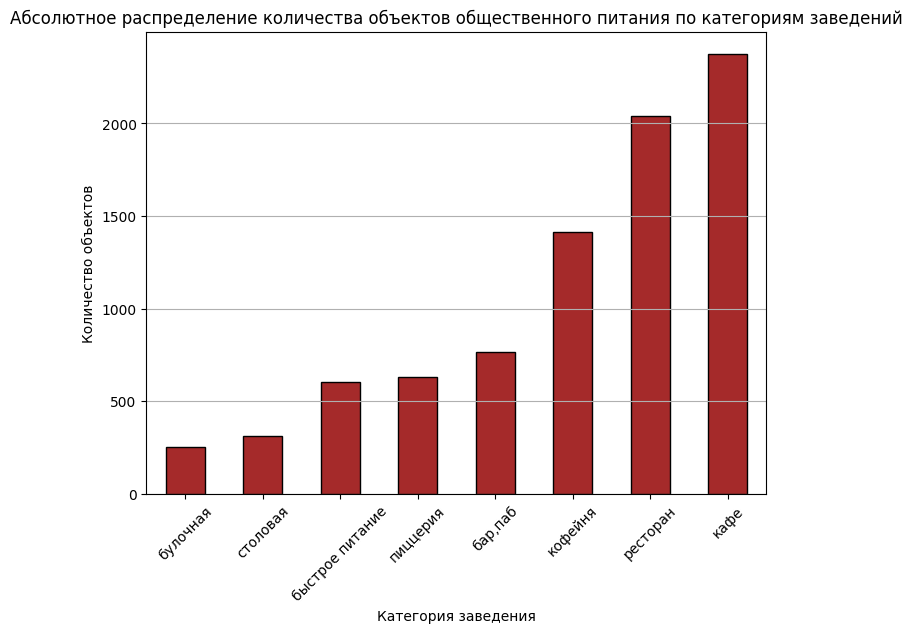

In [54]:
grouped_category_abs.plot(kind='bar', xlabel='Категория заведения', ylabel='Количество объектов', title='Абсолютное распределение количества объектов общественного питания по категориям заведений', color='brown', edgecolor='black', figsize=(8, 6), rot=45).grid(axis='y')

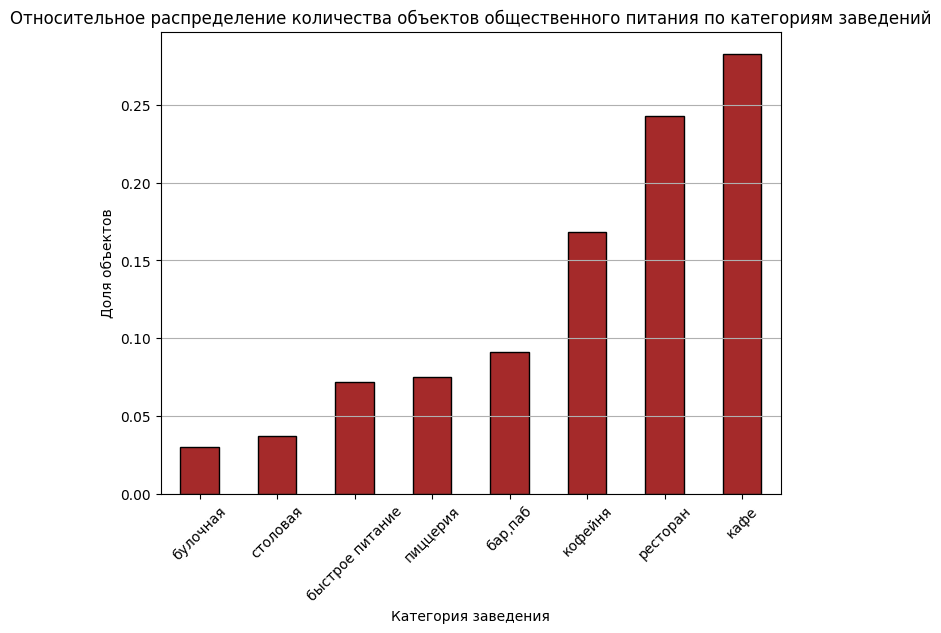

In [55]:
grouped_category_rel.plot(kind='bar', xlabel='Категория заведения', ylabel='Доля объектов', title='Относительное распределение количества объектов общественного питания по категориям заведений', color='brown', edgecolor='black', figsize=(8, 6), rot=45).grid(axis='y')

Наиболее популярной категорией заведений является `кафе`, которому присуще примерно 2350 заведений (примерно 28%), наименее популярной - `булочная` - примерно 250 заведений (примерно 2,5%). 

В целом количество заведений довольно разнозненно. Примерно одинаковое количество присуще `булочной` и `столовой` (около 3%), заведениям типа `быстрое питание`, `пиццерия` (около 7,5%).

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.2-bullet"></a>
### Задача 2

Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. 

Исследуем абсолютное распределение количества заведений по административным районам Москвы.

In [56]:
grouped_district_abs = df.groupby('district')['name'].count().sort_values()
grouped_district_abs = grouped_district_abs.reset_index()
grouped_district_abs

,district,name
0,северо-западный административный округ,409
1,юго-западный административный округ,709
2,юго-восточный административный округ,714
3,восточный административный округ,798
4,западный административный округ,850
5,северо-восточный административный округ,890
6,южный административный округ,892
7,северный административный округ,898
8,центральный административный округ,2242


Исследуем относительное распределение количества заведений по административным районам Москвы.

In [57]:
grouped_district_rel = df['district'].value_counts(normalize=True).sort_values()
grouped_district_rel

district
северо-западный административный округ     0.048679
юго-западный административный округ        0.084385
юго-восточный административный округ       0.084980
восточный административный округ           0.094977
западный административный округ            0.101166
северо-восточный административный округ    0.105927
южный административный округ               0.106165
северный административный округ            0.106879
центральный административный округ         0.266841
Name: proportion, dtype: float64

Визуализируем абсолютное и относительное распределения количества заведений по административным районам Москвы.

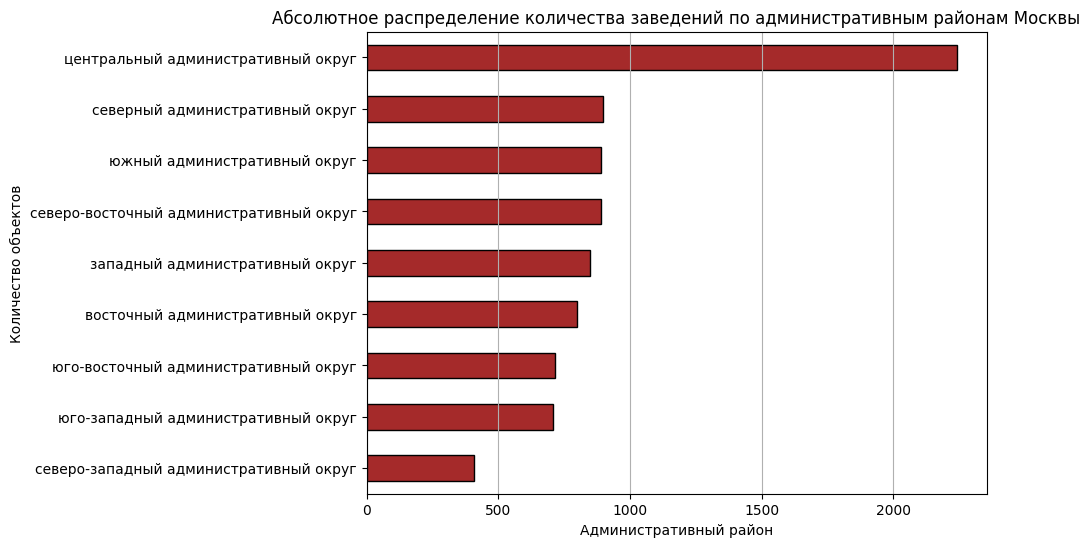

In [58]:
grouped_district_abs.plot(kind='barh', x = 'district', y='name', xlabel='Административный район', ylabel='Количество объектов', title='Абсолютное распределение количества заведений по административным районам Москвы', color='brown', edgecolor='black', figsize=(8, 6), rot=0, legend=False).grid(axis='x')

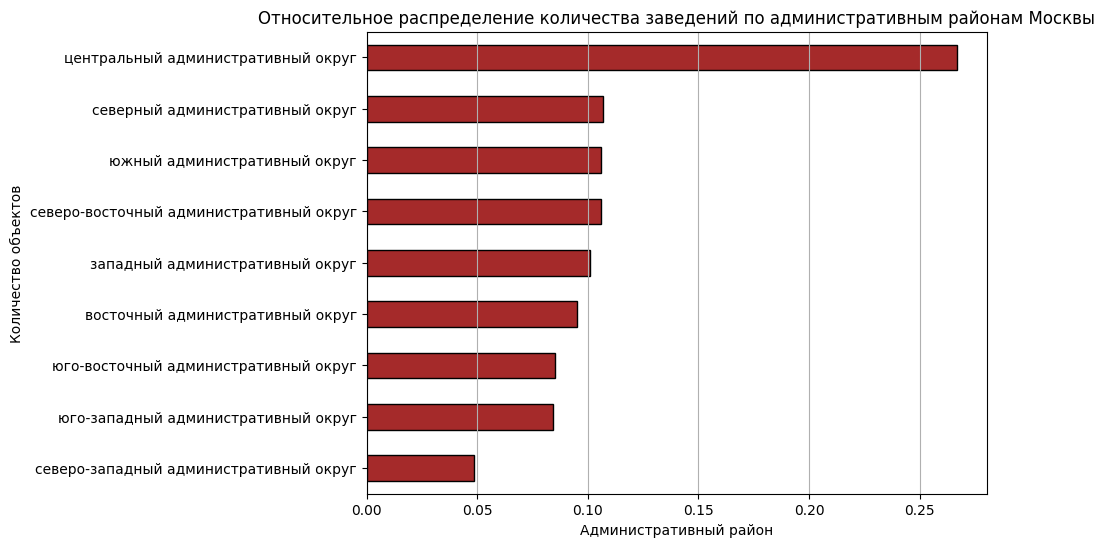

In [59]:
grouped_district_rel.plot(kind='barh', x = 'district', y='name', xlabel='Административный район', ylabel='Количество объектов', title='Относительное распределение количества заведений по административным районам Москвы', color='brown', edgecolor='black', figsize=(8, 6), rot=0, legend=False).grid(axis='x')

Наибольшее количество заведений присуще центральному району (примерно 2200, 27%), наименьшее - северо-западному, примерно 400 (4%). В пределах от 700 до 900 сосредоточено количество заведений во всех остальных районах.

Исследуем распределение заведений каждой категории в Центральном административном округе Москвы.

Выберем все заведения, расположенные в центре.

In [60]:
# посмотрим правильное название центрального административного округа
df['district'].unique()

<StringArray>
[        'северный административный округ',
 'северо-восточный административный округ',
  'северо-западный административный округ',
         'западный административный округ',
      'центральный административный округ',
        'восточный административный округ',
    'юго-восточный административный округ',
            'южный административный округ',
     'юго-западный административный округ']
Length: 9, dtype: str

Отберем заведения, находящиеся в центре, сгруппируем по категориям.

In [61]:
df_center = df[df['district'] == 'центральный административный округ']
grouped_category_center_abs = df_center.groupby('category')['name'].count().sort_values()
grouped_category_center_abs

category
булочная            50
столовая            66
быстрое питание     87
пиццерия           113
бар,паб            364
кофейня            428
кафе               464
ресторан           670
Name: name, dtype: int64

Посмотрим так же относительное распределение категорий заведений в Центральном административном округе.

In [62]:
grouped_category_center_rel = df_center['category'].value_counts(normalize=True).sort_values()
grouped_category_center_rel

category
булочная           0.022302
столовая           0.029438
быстрое питание    0.038805
пиццерия           0.050401
бар,паб            0.162355
кофейня            0.190901
кафе               0.206958
ресторан           0.298840
Name: proportion, dtype: float64

Визуализируем распределение заведений каждой категории в Центральном административном округе Москвы.

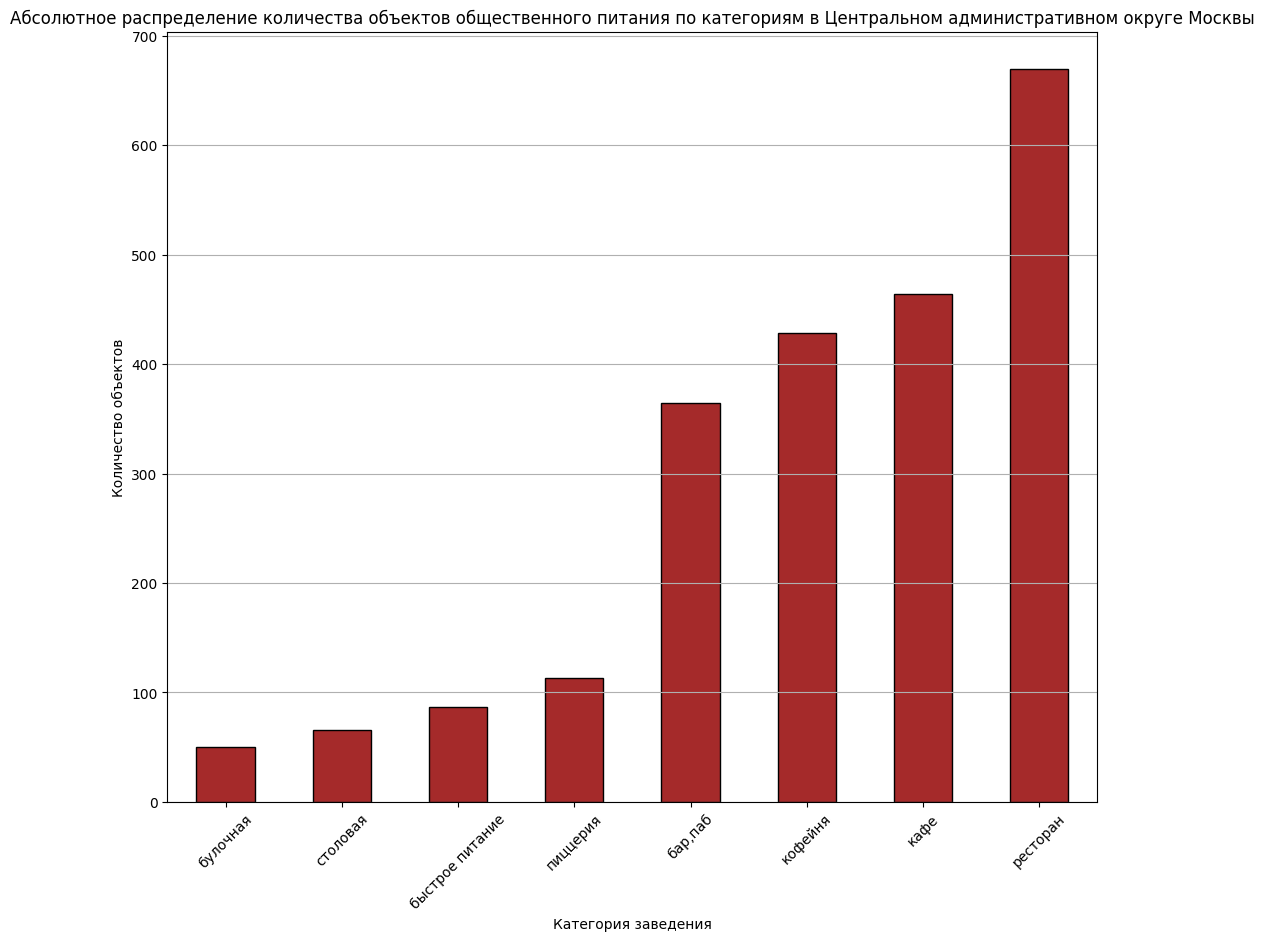

In [63]:
grouped_category_center_abs.plot(kind='bar', xlabel='Категория заведения', ylabel='Количество объектов', title='Абсолютное распределение количества объектов общественного питания по категориям в Центральном административном округе Москвы', color='brown', edgecolor='black', figsize=(12, 10), rot=45).grid(axis='y')

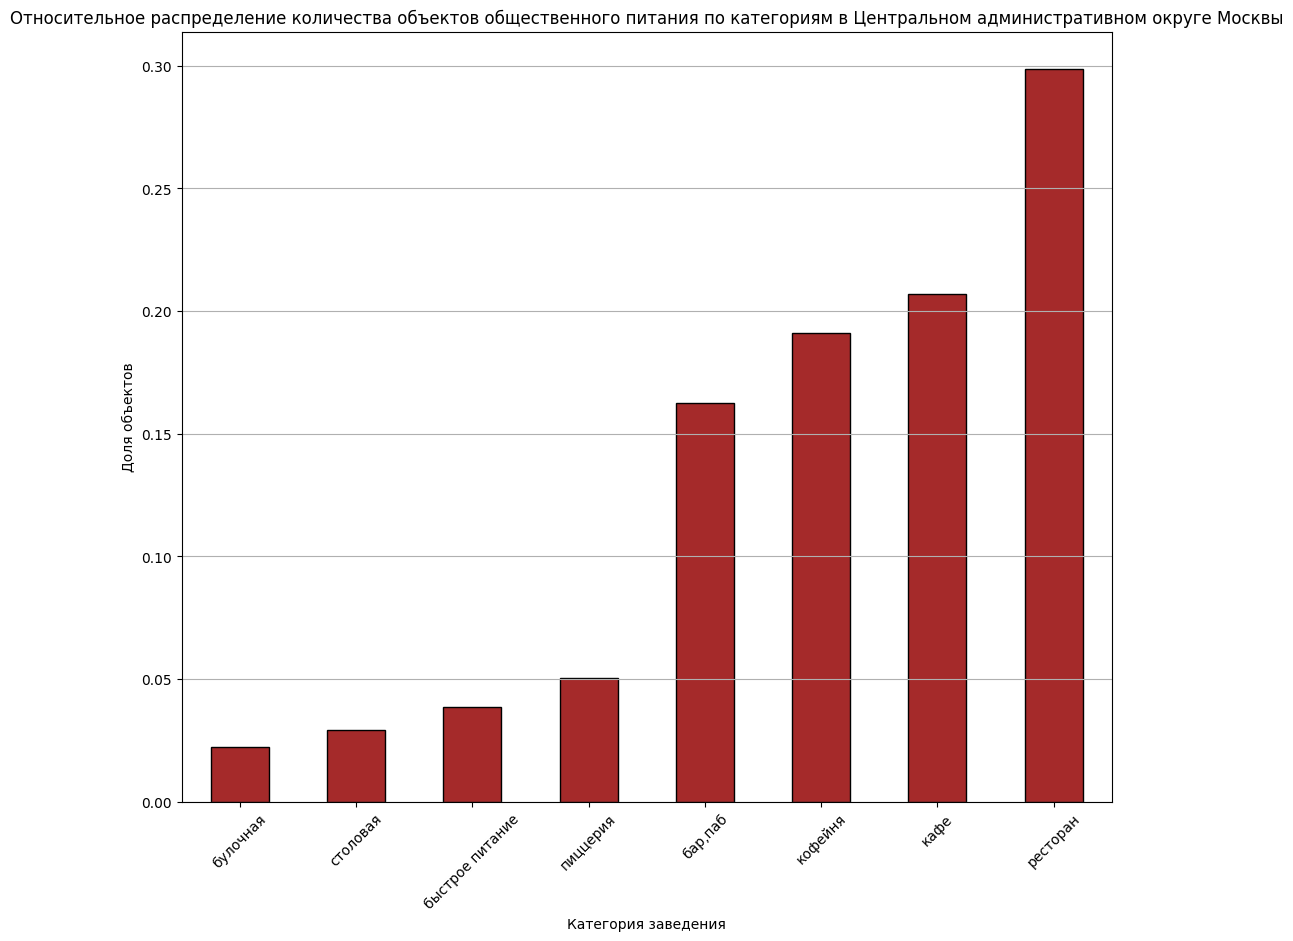

In [64]:
grouped_category_center_rel.plot(kind='bar', xlabel='Категория заведения', ylabel='Доля объектов', title='Относительное распределение количества объектов общественного питания по категориям в Центральном административном округе Москвы', color='brown', edgecolor='black', figsize=(12, 10), rot=45).grid(axis='y')

В Центральном административном округе Москвы:
- Наиболее популярные заведения - рестораны (около 660, 30%);
- Наименее популярные заведения - булочные (около 50, 2.5%);
- Количество баров и пабов, кофеен и кафе значительно больше количества столовых, заведений быстрого питания и пиццерий.

Можно заметить, что в Центральном административном округе наиболее частыми заведениями являются рестораны, а также кафе и кофейны, которых примерно на 10-15% меньше количества ресторанов. В то время по всем округам первое место занимают кафе, на 5% меньше - рестораны и на 5% меньше ресторанов - кофейни. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.3-bullet"></a>
### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.

Найдем относительное распределение количества сетевых и несетвых заведений.

In [65]:
grouped_chain_rel = df['chain'].value_counts(normalize=True)
grouped_chain_rel

chain
0    0.618543
1    0.381457
Name: proportion, dtype: float64

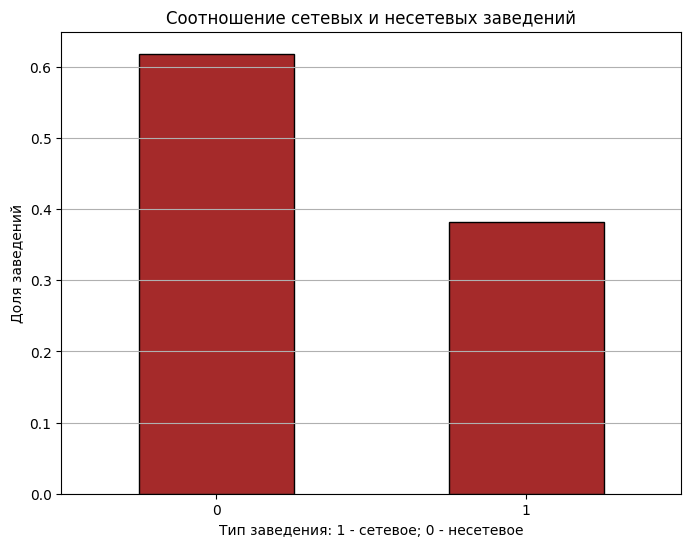

In [66]:
grouped_chain_rel.plot(kind='bar', xlabel='Тип заведения: 1 - сетевое; 0 - несетевое', ylabel='Доля заведений', title='Соотношение сетевых и несетевых заведений', color='brown', edgecolor='black', rot=0, figsize=(8, 6)).grid(axis='y')

Даже с учетом того, что в столбце chain по условию могут встречаться ошибки, можно заметить, что количество несетевых заведений примерно на 42% больше количества сетевых заведений.

Изучим соотношение сетевых и несетевых заведений в разрезе категорий заведения.

In [67]:
grouped_chain_category = df.groupby(['category', 'chain'])['name'].count().unstack()
grouped_chain_category

chain,0,1
category,,
"бар,паб",596,169
булочная,99,156
быстрое питание,371,232
кафе,1597,779
кофейня,693,721
пиццерия,303,330
ресторан,1311,730
столовая,227,88


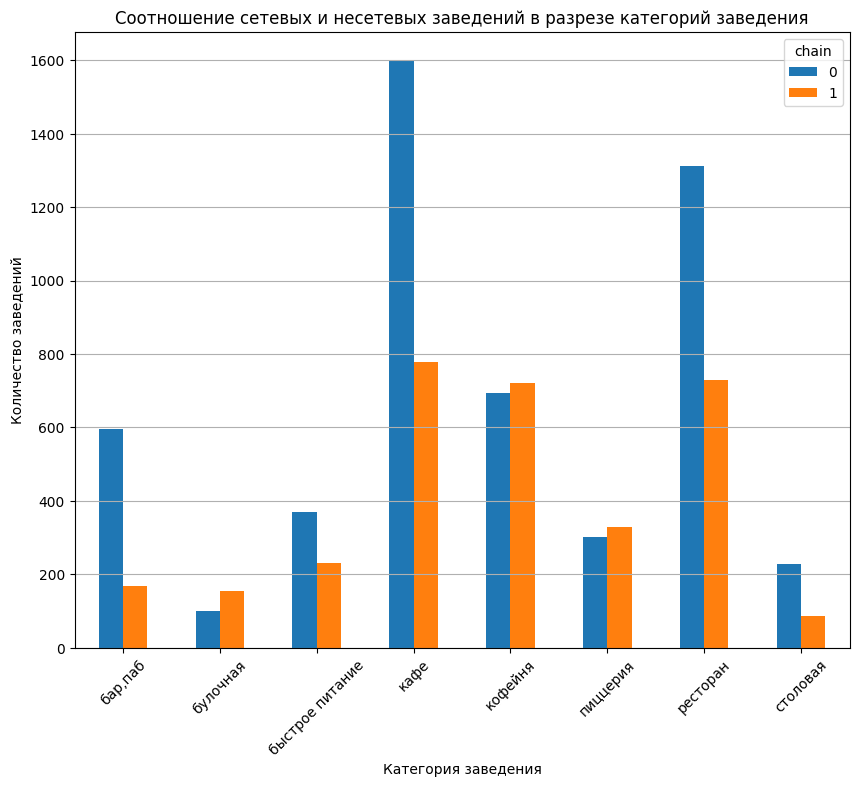

In [68]:
grouped_chain_category.plot.bar(figsize=(10, 8), rot=45, xlabel='Категория заведения', ylabel='Количество заведений', title='Соотношение сетевых и несетевых заведений в разрезе категорий заведения').grid(axis='y')

Изучим относительное распределение сетевых заведений по категориям заведений.

In [69]:
grouped_chain_1 = df.groupby(by='category')['chain'].value_counts(normalize = True).unstack()[1].sort_values(ascending=False)
grouped_chain_1

category
булочная           0.611765
пиццерия           0.521327
кофейня            0.509901
быстрое питание    0.384743
ресторан           0.357668
кафе               0.327862
столовая           0.279365
бар,паб            0.220915
Name: 1, dtype: float64

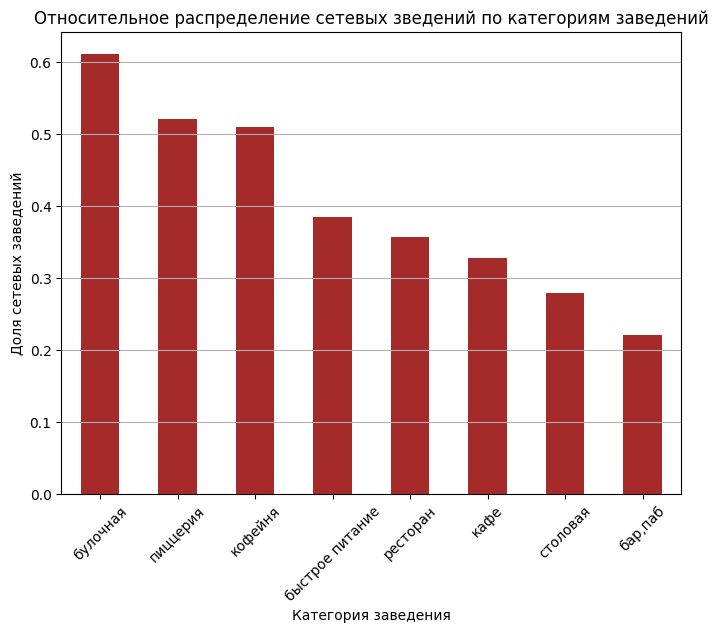

In [70]:
grouped_chain_1.plot(kind='bar', title='Относительное распределение сетевых зведений по категориям заведений', rot=45, xlabel='Категория заведения', ylabel='Доля сетевых заведений', color='brown', figsize=(8, 6)).grid(axis='y')

По графикам можно сделать следующие выводы:
- для категорий `булочная`, `кофейня`, `пиццерия` над количеством несетевых заведений преобладает количество сетевых (сетевых заведений примерно 61%, 52%, 51% соот-но), для остальных категорий ситуация обратная;
- для `баров, пабов` характерно наибольшее преобладание более чем в 3 раза несетевых заведений над сетевыми (сетевых заведений примерно 22%);
- для `кофеен` и `пиццерий` характерное примерное равенство сетевых и несетевых заведений.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.4-bullet"></a>
### Задача 4

Исследуем количество посадочных мест в заведениях. Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест.


Отберем строки, где элементы не были заменены значениями-индикаторами.

In [72]:
df_seats = df[df['seats'] != -1]

Построим гистограмму и диаграмму размаха для исследования столбца.

In [73]:
min_value = df_seats['seats'].describe()['min']
max_value = df_seats['seats'].describe()['max']
print(min_value, max_value)

0.0 1288.0


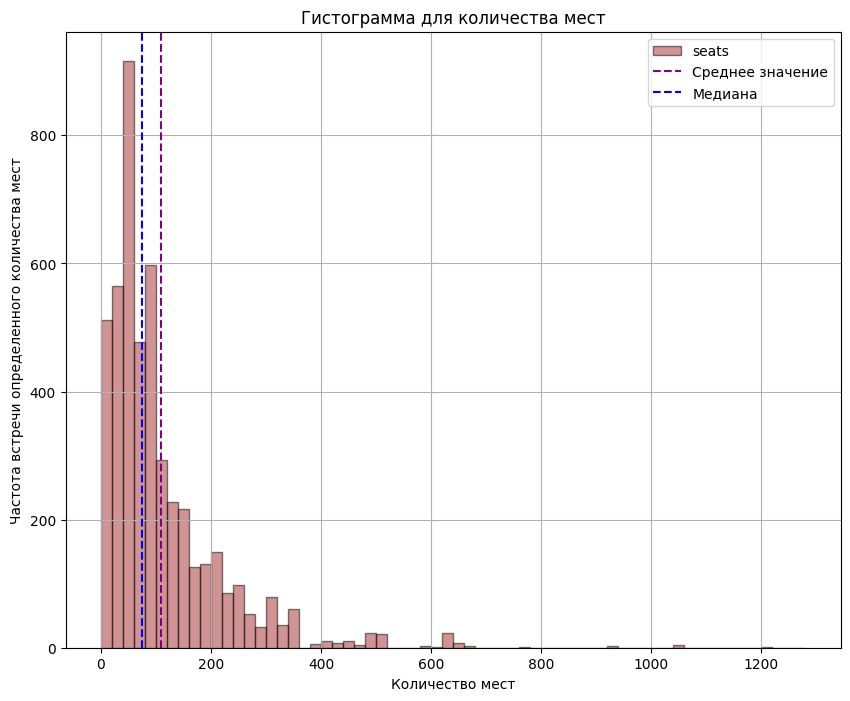

In [74]:
df_seats['seats'].plot(kind='hist', title='Гистограмма для количества мест', figsize=(10, 8), bins=range(int(min_value), int(max_value) + 1, 20), color='brown', alpha=0.5, edgecolor='black', grid=True, legend=True)
plt.xlabel('Количество мест')
plt.ylabel('Частота встречи определенного количества мест')
plt.axvline(df_seats['seats'].mean(), linewidth=1.5, label='Среднее значение', linestyle='--', color='purple')
plt.axvline(df_seats['seats'].median(), linewidth=1.5, label='Медиана', linestyle='--', color='blue')
plt.legend()

Построим диаграмму размаха сначала с отображением выбросов, а потом без отображения выбросов (так как выбросов много, надо исключить проблему отображения основной массы данных).

Изменим множитель IQR на 3, так как данные сильно вариабельны, чтобы не исключить на самом деле корректные значения. 

Text(0.5, 0, 'Количество мест')

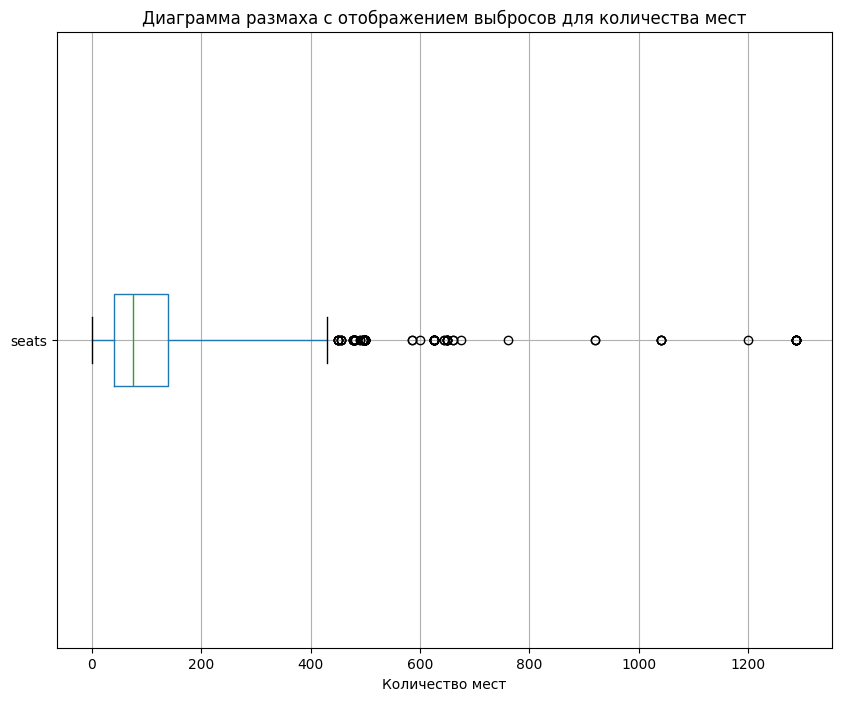

In [75]:
df_seats.boxplot('seats', vert=False, figsize=(10, 8), whis=3) 
plt.title('Диаграмма размаха с отображением выбросов для количества мест')
plt.xlabel('Количество мест')

Text(0.5, 0, 'Количество мест')

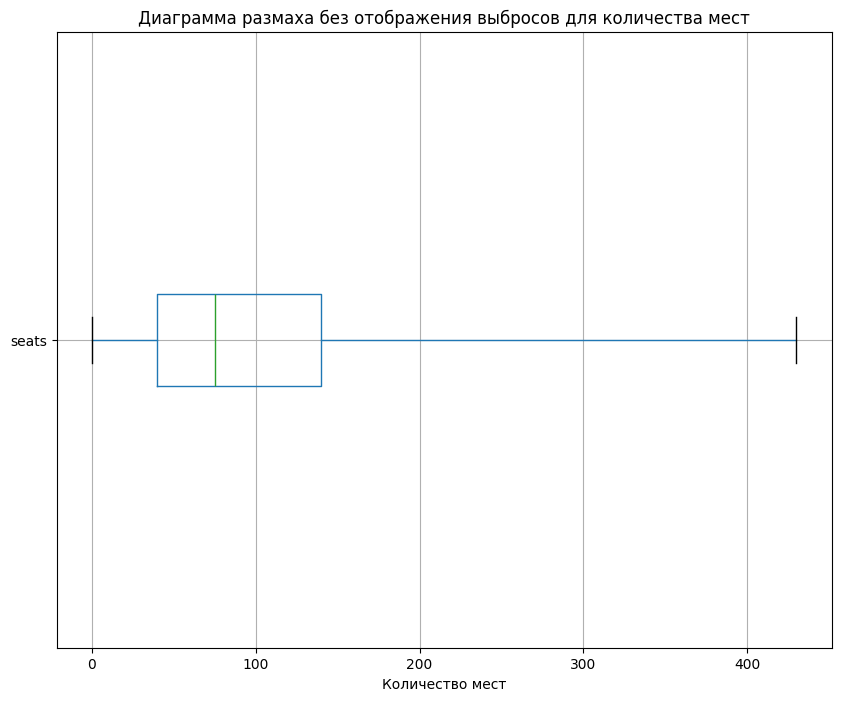

In [76]:
df_seats.boxplot('seats', vert=False, figsize=(10, 8), showfliers=False, whis=3) 
plt.title('Диаграмма размаха без отображения выбросов для количества мест')
plt.xlabel('Количество мест')

Распределение столбца с количество мест правоассиметричное, среднее значение находится правее медианы, медиана смещена к началу распределения (около 20). Данные вариативны, так как при построении диаграммы пришлось увеличить множитель IQR из-за наличия некорректно большого количества выбросов, которые скорее всего таковыми не являются. 

В данных имеется большое количество выбросов в правой части, наличие которых может быть связано с ошибками сбора данных либо в частных случаях с наличием у заведений очень большого количества мест. 

Найдем для каждой категории заведений наиболее типичное количество посадочных мест с помощью медианы.

In [77]:
grouped_typical_seats = df_seats.groupby('category')['seats'].median().sort_values(ascending=False)
grouped_typical_seats

category
ресторан           86.0
бар,паб            82.5
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

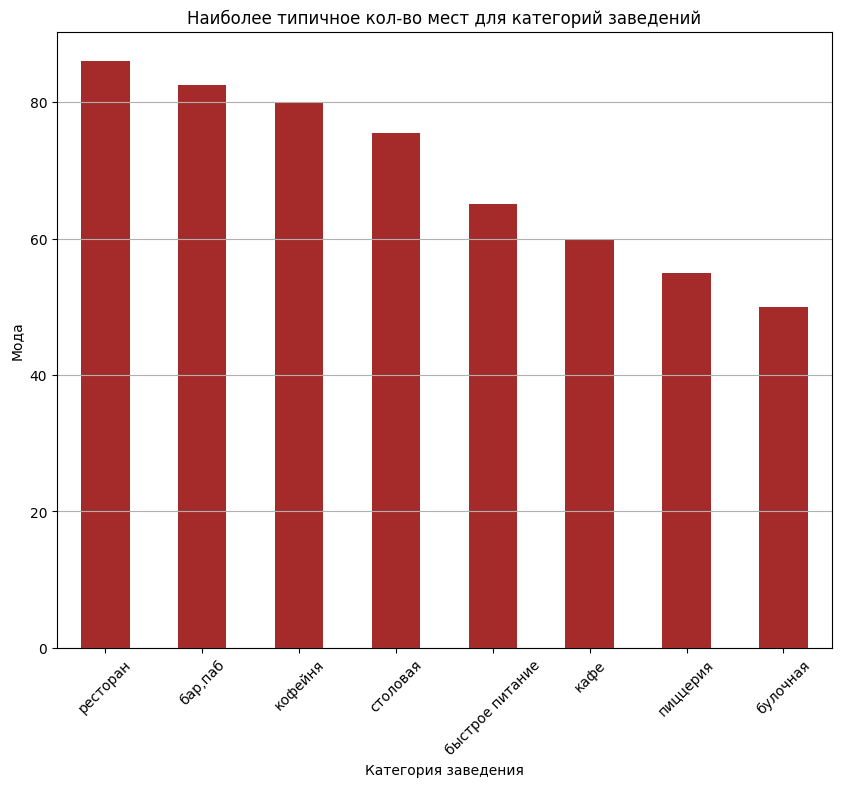

In [78]:
grouped_typical_seats.plot(kind='bar', title='Наиболее типичное кол-во мест для категорий заведений', xlabel='Категория заведения', ylabel='Мода', color='brown', rot=45, figsize=(10, 8)).grid(axis='y')

Наиболее типичное количество мест для заведений варьируется от 50 до 85. Наименьшее количество заведений - примерно 50 - характерно для булочных, наибольшее количество заведений - примерно 85 - для ресторанов.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.5-bullet"></a>
### Задача 5

Исследуем рейтинг заведений. Визуализируем распределение средних рейтингов по категориям заведений.

Исследуем рейтинги заведений

In [79]:
df['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

По сводной информации можно увидеть, что значения рейтингов варьируются в пределах от 1 до 5, среднее значение рейтинга составляет примерно 4,2. Медиана равна 4,3, то есть 50% оценок выше этой отметки.

Посмотрим на распределение средних рейтингов по категориям заведений.

In [80]:
grouped_rating = df.groupby('category')['rating'].describe()['mean'].sort_values(ascending=False)
grouped_rating

category
бар,паб            4.387712
пиццерия           4.301264
ресторан           4.290348
кофейня            4.277157
булочная           4.269020
столовая           4.211429
кафе               4.124284
быстрое питание    4.050249
Name: mean, dtype: float64

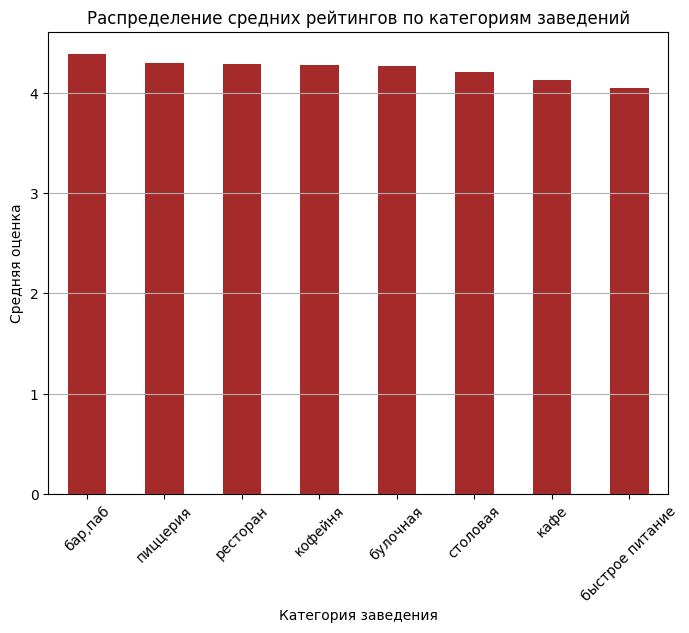

In [81]:
grouped_rating.plot(kind='bar', xlabel='Категория заведения', ylabel='Средняя оценка', rot=45, title='Распределение средних рейтингов по категориям заведений', figsize=(8, 6), color='brown').grid(axis='y')

Средние рейтинги в зависимости от категории заведения варьируются в пределах от 4 до 4,4. Заведения быстрого питания имеют наименьший средний рейтинг (примерно 4), а бары и пабы - наибольший (примерно 4,5). Таким образом, клиенты баров и пабов в среднем остаются более удовлетворены сервисом и блюдами, нежели посетители других заведений.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.6-bullet"></a>
### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными.

Создадим копию датасета и заменим заглушки на пропуски.

In [82]:
df_copy = df.copy()

Заменим заглушки на пропуски.

In [83]:
df_copy['hours'] = df_copy['hours'].replace('', np.nan)
df_copy['hours'].isna().sum()

np.int64(537)

In [84]:
df_copy['price'] = df_copy['price'].replace('', np.nan)
df_copy['price'].isna().sum()

np.int64(5087)

In [85]:
df_copy['middle_avg_bill'] = df_copy['middle_avg_bill'].replace(-1, np.nan)
df_copy['middle_avg_bill'].isna().sum()

np.int64(5253)

In [86]:
df_copy['seats'] = df_copy['seats'].replace(-1, np.nan)
df_copy['seats'].isna().sum()

np.int64(3610)

In [87]:
df_copy.seats.min()

np.float64(0.0)

Создадим матрицу корреляции

In [88]:
correlation_matrix = df_copy[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix()
correlation_matrix

interval columns not set, guessing: ['rating', 'chain', 'seats']


,rating,category,district,chain,seats,price,is_24_7
rating,1.000000,0.198835,0.189453,0.119212,0.000000,0.262056,0.161010
category,0.198835,1.000000,0.174386,0.265325,0.048661,0.566933,0.244853
district,0.189453,0.174386,1.000000,0.064447,0.352440,0.202787,0.076357
chain,0.119212,0.265325,0.064447,1.000000,0.057584,0.218211,0.043227
seats,0.000000,0.048661,0.352440,0.057584,1.000000,0.088146,0.043193
price,0.262056,0.566933,0.202787,0.218211,0.088146,1.000000,0.084183
is_24_7,0.161010,0.244853,0.076357,0.043227,0.043193,0.084183,1.000000


In [89]:
# оставим значения только для рейтинга
correlation_rating = pd.DataFrame(correlation_matrix['rating'][1:].sort_values())
correlation_rating

,rating
seats,0.000000
chain,0.119212
is_24_7,0.161010
district,0.189453
category,0.198835
price,0.262056


Text(0.5, 23.52222222222222, 'Рейтинг')

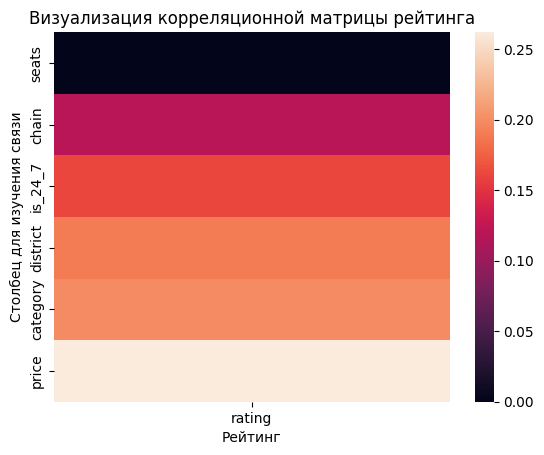

In [90]:
sns.heatmap(correlation_rating)
plt.title('Визуализация корреляционной матрицы рейтинга')
plt.ylabel('Столбец для изучения связи')
plt.xlabel('Рейтинг')

Рейтинг со всеми столбцами показывает довольно слабую корреляцию. Наиболее сильная корреляция со столбцом `price` - примерно 0,25. Проверим ее.

Найдем средний рейтинг для разных ценовых категорий заведений.

In [91]:
grouped_rating_price = df_copy.groupby('price')['rating'].mean().sort_values()
grouped_rating_price

price
низкие           4.173077
средние          4.297874
выше среднего    4.386347
высокие          4.436611
Name: rating, dtype: float32

<Axes: title={'center': 'Зависимость рейтинга от ценовой категории заведения'}, xlabel='Ценовая категория', ylabel='Средний рейтинг'>

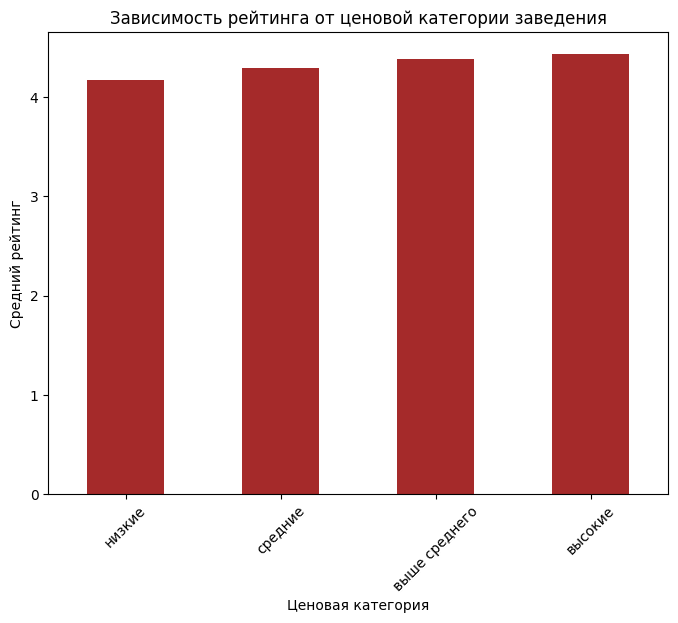

In [92]:
grouped_rating_price.plot(kind='bar', title='Зависимость рейтинга от ценовой категории заведения', xlabel='Ценовая категория', ylabel='Средний рейтинг', rot=45, color='brown', figsize=(8, 6))

Можно увидеть, что средний рейтинг зависит от ценовой категории. Чем выше ценовая категория заведений, тем выше средний рейтинг. Так, заведениям с низкими ценами соответствует рейтинг примерно 4.1, а заведениям с высокими ценами - примерно 4.5. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.7-bullet"></a>
### Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга.

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Параллельно посчитаем для них средний рейтинг.

In [93]:
# создадим датафрейм с сетями
df_chain = df[df['chain'] == 1]
grouped_name = df_chain.groupby(by=['name', 'category']).agg({'address': 'count', 'rating': 'mean'}).sort_values(by='address', ascending=False).head(15).reset_index().sort_values(by='rating').rename(columns={'address':'count_objects', 'rating': 'mean_rating'})
grouped_name

,name,category,count_objects,mean_rating
4,яндекс лавка,ресторан,69,3.872464
11,чайхана,кафе,26,3.946154
10,cofefest,кофейня,31,3.977419
13,drive café,кафе,24,4.025000
3,one price coffee,кофейня,71,4.064789
5,cofix,кофейня,65,4.075385
9,теремок,ресторан,36,4.105556
6,prime,ресторан,49,4.114285
7,кофепорт,кофейня,42,4.147619
1,домино'с пицца,пиццерия,76,4.169737


In [95]:
tmp = df.copy()   
name_tmp = 'му-му'   
print(f'Заведения с одинаковым именем {name_tmp} относятся к разным категориям:\n\
{", ".join(tmp[tmp.name == name_tmp].category.unique())}')

Заведения с одинаковым именем му-му относятся к разным категориям:
кафе, ресторан, кофейня, быстрое питание, пиццерия, столовая, бар,паб


Text(0, 0.5, 'Название сети заведений')

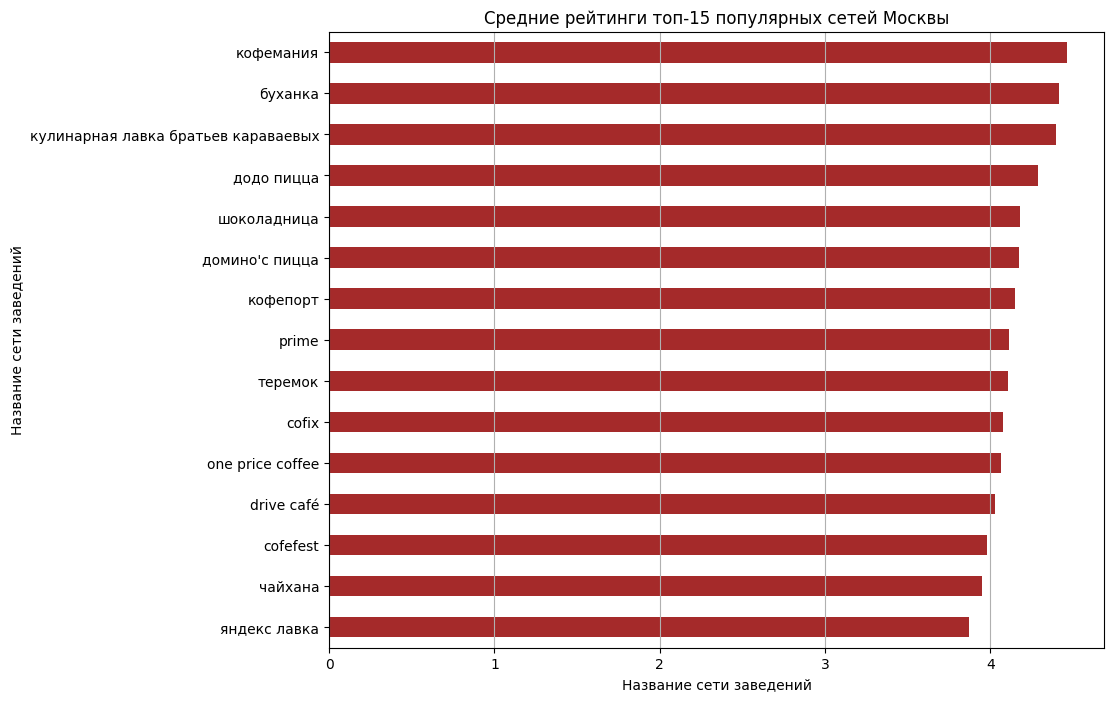

In [96]:
grouped_name.plot(kind='barh', x='name', y='mean_rating', xlabel='Название сети заведений', legend=False, color='brown', title='Средние рейтинги топ-15 популярных сетей Москвы', figsize=(10, 8), rot=0).grid(axis='x')
plt.ylabel('Название сети заведений')

Средние рейтинги топ-15 популярных сетей Москвы варируются в пределах от 3.8 до 4.5. Наибольший рейтинг присущ сети "Кофемания", наименьший - сети "Яндекс лавка".

Визуализируем количество заведений каждой сети.

In [97]:
# отсортируем по количеству заведений
grouped_name = grouped_name.sort_values(by='count_objects')
grouped_name

,name,category,count_objects,mean_rating
14,кофемания,кофейня,22,4.463636
13,drive café,кафе,24,4.025000
12,буханка,булочная,25,4.416000
11,чайхана,кафе,26,3.946154
10,cofefest,кофейня,31,3.977419
9,теремок,ресторан,36,4.105556
8,кулинарная лавка братьев караваевых,кафе,39,4.394872
7,кофепорт,кофейня,42,4.147619
6,prime,ресторан,49,4.114285
5,cofix,кофейня,65,4.075385


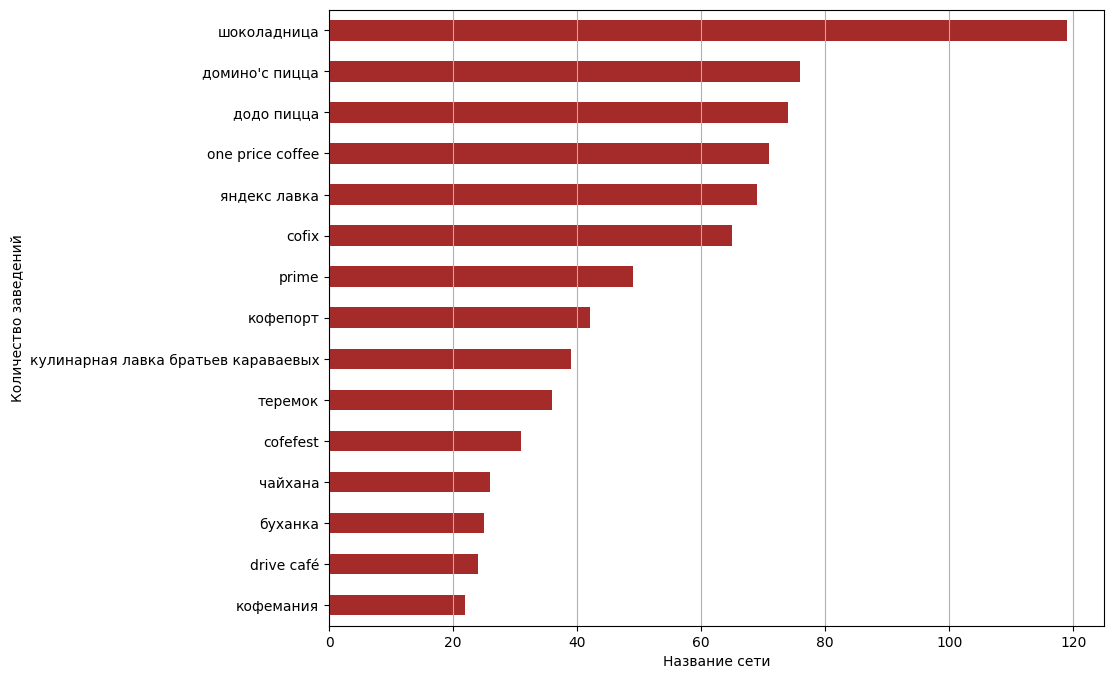

In [98]:
grouped_name.plot(kind='barh', x = 'name', y='count_objects', color='brown', figsize=(10, 8), xlabel='Название сети', ylabel='Количество заведений', rot=0, legend=False).grid(axis='x')

Наибольшее количество заведений у топ-15 сетей принадлежит сети "Шоколадница" и составляет примерно 120 точек. Наименьшее количество заведений присуще сети "Кофемания" и составляет 22 заведения. 

Найдем уникальные значения категорий топ-15 заведений.

In [99]:
grouped_name['category'].unique()

<StringArray>
['кофейня', 'кафе', 'булочная', 'ресторан', 'пиццерия']
Length: 5, dtype: str

Таким образом, топ-15 сетям принадлежат такие категории заведений, как `кофейня`, `кафе`, `булочная`, `ресторан` и `пиццерия`. Наибольший рейтинг, равный примерно 4.5, принадлежит сети заведений "Кофемания", имеющей наименьшее количество точек, равное 22. Наименьший рейтинг, равный примерно 3.8, принадлежит сети "Яндекс лавка", количество заведений которой равно примерно 70. Наибольшее количество точек, равное примерно 120, принадлежит "Шоколаднице", рейтинг которой около 4.2. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---
<a class="anchor" id="3.8-bullet"></a>
### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. 


Отсортируем датафрейм, оставив только данные, не заполненные значениями-индикаторами.

In [100]:
df_avg_bill = df[df['middle_avg_bill'] != -1]

Проанализируем статистические показатели данных по среднему чеку заведений. 

In [101]:
df_avg_bill['middle_avg_bill'].describe()

count     3149.000000
mean       958.053650
std       1009.732849
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

Среднее значение по столбцу со средним чеком заведений примерно равно 960. Значения столбца варьируются в пределах 35000. 50% данных имеют значения больше 750. Среднеквадратичное отклонение равно примерно 1010. 

Построим гистограмму и диаграмму размаха с выбросами и без выбросов для столюца со средним чеком заведений.

Text(0.5, 1.0, 'Гистограмма для столбца со средним чеком')

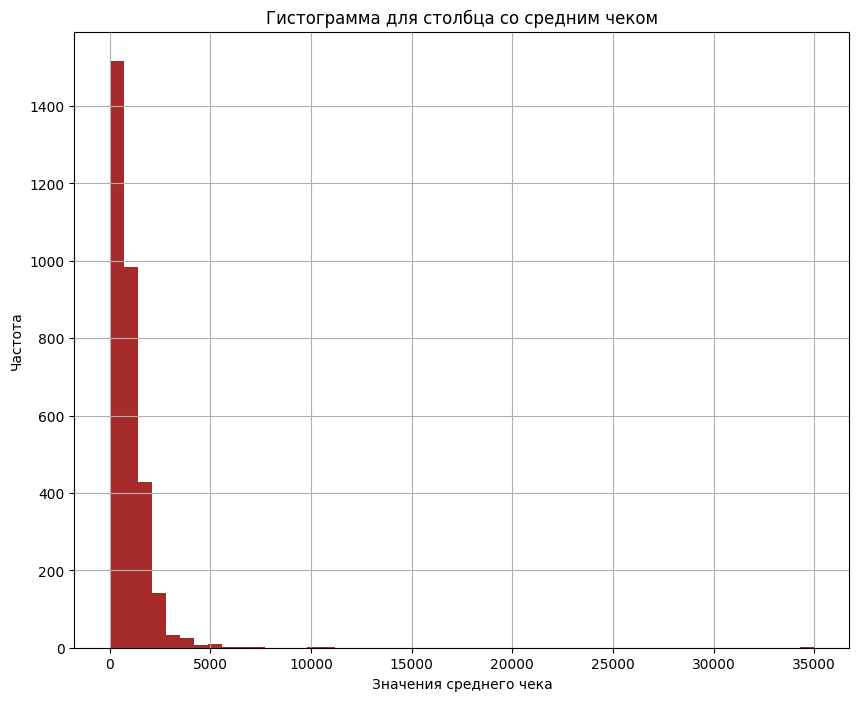

In [102]:
df_avg_bill['middle_avg_bill'].plot(kind='hist', bins=50, color='brown', figsize=(10, 8), legend=False, grid=True)
plt.ylabel('Частота')
plt.xlabel('Значения среднего чека')
plt.title('Гистограмма для столбца со средним чеком')

Распределение столбца со средним чеком правоассиметричное, среднее значение расположено правее медианы, большинство значений расположено в диапазоне от 0 до 5000.

Text(0.5, 1.0, 'Диаграмма размаха без выбросов для столбца со средними значениями чека')

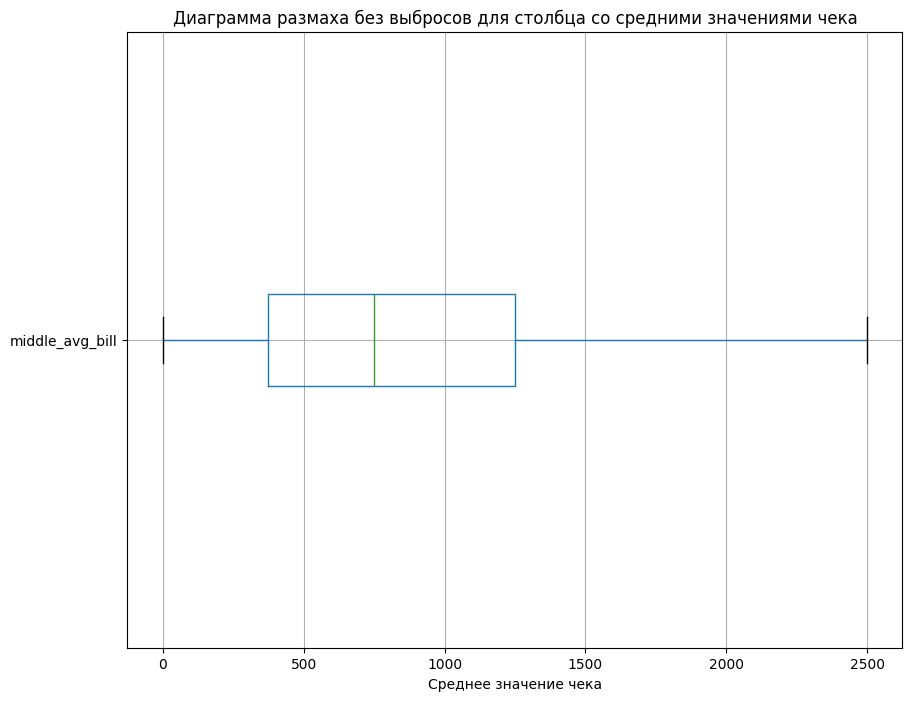

In [103]:
df_avg_bill.boxplot('middle_avg_bill', vert=False, figsize=(10, 8), showfliers=False)
plt.xlabel('Среднее значение чека')
plt.title('Диаграмма размаха без выбросов для столбца со средними значениями чека')

Text(0.5, 1.0, 'Диаграмма размаха с выбросами для столбца со средними значениями чека')

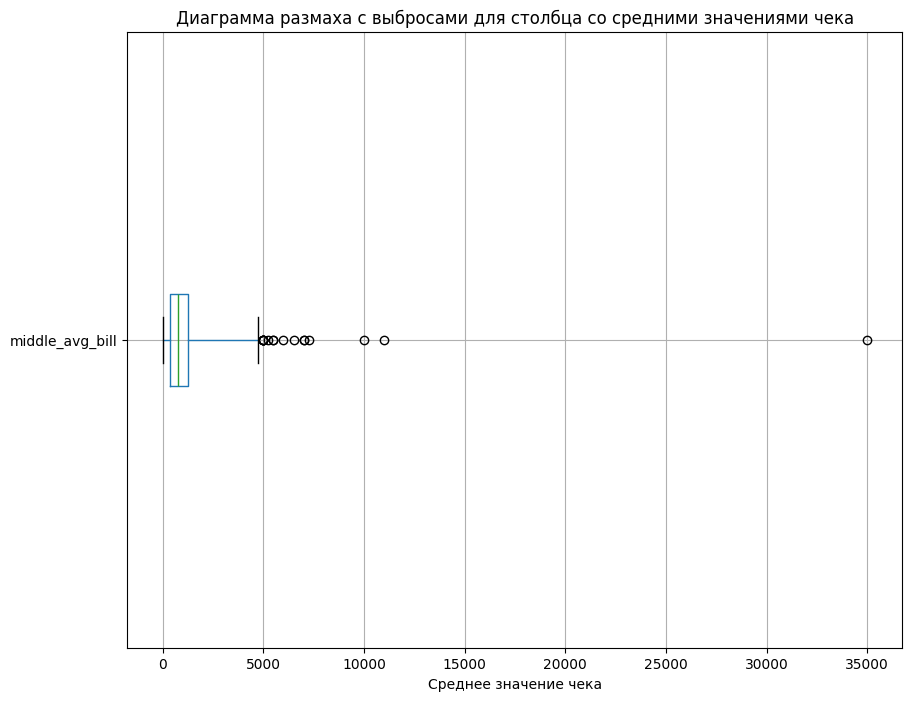

In [104]:
df_avg_bill.boxplot('middle_avg_bill', vert=False, whis=4, figsize=(10, 8))
plt.xlabel('Среднее значение чека')
plt.title('Диаграмма размаха с выбросами для столбца со средними значениями чека')

Из диаграмм размаха так же видно, что распределение правоассиметричное, медиана смещена влево, размах равен 35000, данные вариабельны, из-за чего был увеличен множитель IQR для отражения выбросов. Имеется большое количество выбросов справа, в основном сосредоточенных в пределах от 5000 до 10000.

Изучим вариацию среднего чека заведения в зависимости от района Москвы.

In [105]:
grouped_middle_avg_bill = df_avg_bill.groupby(by='district')['middle_avg_bill'].describe()[['mean', '50%']].rename(columns={'50%':'median'}).sort_values(by='mean')
grouped_middle_avg_bill

,mean,median
district,,
юго-восточный административный округ,654.097961,450.0
северо-восточный административный округ,716.611267,500.0
юго-западный административный округ,792.561707,600.0
восточный административный округ,820.626953,575.0
северо-западный административный округ,822.222900,700.0
южный административный округ,834.398071,500.0
северный административный округ,927.959656,650.0
западный административный округ,1053.225464,1000.0
центральный административный округ,1191.057495,1000.0


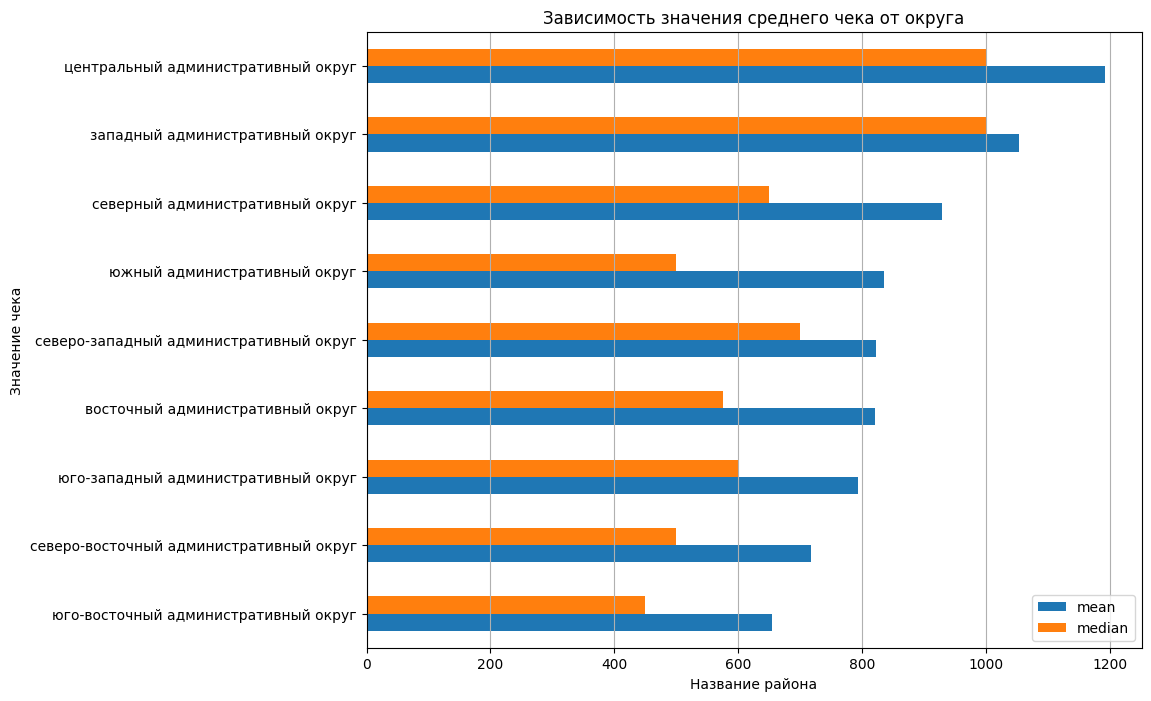

In [106]:
grouped_middle_avg_bill.plot.barh(xlabel='Название района', ylabel='Значение чека', title='Зависимость значения среднего чека от округа',  figsize=(10, 8)).grid(axis='x')

Наибольший средний чек присущ центральному району, вероятно, из-за того, что большинство заведений в центре - рестораны, ценовой сегмент которых оносится к "высоким". При этом по сравнению с другими количество ресторанов в целом преобладает в этом районе.  Заведения, не находящиеся в центре, имеют менее высокие чеки. Так, наименьший средний чек у юго-восточного и северо-восточного районов (в пределах 650-700). Причина снижения среднего чека, скорее всего, отдаление от центра и меньшее количество точек общественного питания. Все округи имеют правоассиметричное распределение, наиболее близко к симметричному распределению западный административный округ. Это говорит о том, что для каждого округа выбросы для столбца со средним чеком расположены справа, наименьшее количество выбросов присуще западному административному округу.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

---

### Промежуточный вывод


---
Обобщение полученных результатов:
- Наиболее частыми заведениями являются кофейни, рестораны и кафе;
- Наиболее редкими заведениями являются булочные, столовые и заведения быстрого питания;
- Наибольшее количество заведений сосредоточено в центральном районе, наименьшее - в северо-западном;
- Несетевых заведений примерно на 42% больше, чем сетевых по общим данным;
- Больше всего в своих категориях сетевых булочных, кофеен и пиццерий, меньше всего - сетевых баров, пабов;
- Наиболее типичное количество мест для заведений варьируется от 50 до 85. Наименьшее количество заведений - примерно 50 - характерно для булочных, наибольшее количество заведений - примерно 85 - для ресторанов;
- Все заведения в основном имеют хороший рейтинг от 4 до 4,4;
- Рейтинги не зависят от категории заведения, имеют небольшую зависимость от ценовой категории;
- У топ-15 распространенных сетевых заведений средние оценки находятся в диапазонах от 3,8 до 4,5;
- Наибольший чек достигается в центральном районе. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="4-bullet"></a>
## 4. Итоговый вывод и рекомендации

---
Целью и задачей выполнения проекта был анализ датасета, содержащего в себе данные о заведениях общественного питания Москвы, составленный на основе данных на лето 2022 года, и предоставление инвесторам актуальной информации об объектах питания в Москве, чтобы они смогли подобрать оптимальный для себя тип заведения, его расположение и т.д. для открытия новой точки.

В результате работы были загружены и изучены данные датасетов rest_info.csv и rest_price.csv, подготовлен единый датафрейм для дальнейшего анализа. Датафрейм был предобработан: изменены типы данных, обработаны пропущенные значения, проведена проверка дубликатов, создан столбец `is_24_7` для дальнейшей работы. Путем рассмотрения гистограмм, столбчатых диаграмм, диаграмм размаха, тепловых карт; изучения зависимостей в числах, построени визуализаций в целом, была проведена обработка данных.

В ходе выполнения предобработка данных были:
- Изменены типы данных столбцов `rating`, `chain`, `seats`. Понижена раздрядность столбцов `middle_avg_bill`, `middle_coffee_cup`;
- Проанализированы причины пропусков во всех столбцах, предложены способы работы с пропусками. В столбцах `seats`, `hours`, `price`, `middle_avg_bill` проведены замены пропусков значениями-индикаторами;
- Нормализованы категориальные данные;
- Выявлено отсутствие явных дубликатов;
- Выявлено наличие 4 неявных дубликатов. Проведен анализ строк-неявных дубликатов, редактирование оставшихся после удаления строк, чтобы данные были не искажены.

Предобработка данных позволила получить корректные результаты при анализе данных. По анализу данных можно сформулировать следующие рекомендации для заказчиков. 

Выбор места для открытия заведения зависит в основном от решения инвесторов. Исходя из данных, наиболее прибыльные места сосредоточены в центральном районе, но при этом количество открытых точек там так же самое большое. В остальных районах количество объектов примерно одинаковое, но средний чек немного варьируется - после центрального района самый большой чек принадлежит западному району, самый маленький - юго-восточному. Рейтинг заведения будет зависеть от работы точки, так как нельзя сказать, что на него сильно влияют внешний факторы, за иклюением ценовой категории заведения - чем выше категория, тем выше будет средний чек. На рынке сетевых заведений меньше, чем несетевых, что оставляет больше пространства для развития новой сети заведений. Но при открытии сети необходимо учитывать и категорию заведения. Для одних категорий сетевые заведения более свойственны, для других - менее. Количество посадочных мест определяется владельцами, но при этом стоит учитывать типичные значения - так, рестораны и бары, пабы требуют большего количества мест, пиццерии и булочные - меньшего.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>